# EDA para los datos operacionales del compresor

1. ¿Cómo se ven las distribuciones ahora sin los ceros?
2. ¿Cómo se comportan las señales ANTES de cada falla?
3. ¿Qué tan correlacionadas están las señales entre sí?
4. ¿Cuánta autocorrelación hay para poder definir el tamaño de ventana
5. ¿Cuánto cuánto fallan las señales antes de la falla para poder validar RUL_MAX?

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

sns.set_style('whitegrid')

ANALOG_COLS  = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
                'Oil_temperature', 'Motor_current', 'Caudal_impulses']
BINARY_COLS  = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
                'Pressure_switch', 'Oil_level']

In [43]:
df = pd.read_parquet('../data/processed/df_operacion.parquet')
print(f'Número de registros: {len(df):,}')
df

Número de registros: 114,740


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,id_segmento,regimen,diff_seg,nuevo_segmento
0,2020-02-01 00:23:00,7.468667,8.511667,1.282667,-0.023333,8.509667,49.712500,5.740833,0.0,1.0,0.0,0.0,0.0,1.0,1.0,6.0,0,2,NaN,False
1,2020-02-01 00:24:00,8.343000,9.773000,1.671333,-0.023000,9.769333,49.854167,5.814167,0.0,1.0,1.0,0.0,0.0,1.0,1.0,6.0,0,2,60.0,False
2,2020-02-01 00:25:00,-0.020000,9.978333,9.970333,-0.022333,9.977000,51.975000,3.881667,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,60.0,False
3,2020-02-01 00:26:00,-0.013333,9.860667,9.847000,-0.022667,9.860667,53.654167,3.865833,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,60.0,False
4,2020-02-01 00:27:00,-0.012000,9.781000,9.766000,-0.022333,9.781000,53.241667,3.876250,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,60.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114735,2020-09-01 03:49:00,-0.013667,9.817000,9.805000,-0.021667,9.816667,67.154167,3.887500,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,10409,1,60.0,False
114736,2020-09-01 03:50:00,-0.012000,9.710333,9.696667,-0.021000,9.710000,65.625000,3.925000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,10409,1,60.0,False
114737,2020-09-01 03:51:00,-0.012000,9.612333,9.598333,-0.021000,9.612000,64.737500,3.863750,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,10409,1,60.0,False
114738,2020-09-01 03:52:00,-0.012000,9.519000,9.505667,-0.021000,9.519000,64.541667,3.896250,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,10409,1,60.0,False


#### Descripción datos de operación
- Se puede ver que dentro de cada segmento presente en estos datos, el régimen del compresor se puede ir alternando y eso representa el comportamiento real del sistema.
- Es el comportamiento real con cada una de las señales a analizar en el EDA.

In [44]:
print(f"Rango temporal   : {df['timestamp'].min()}  hasta  {df['timestamp'].max()}")
print(f"Duración total   : {df['timestamp'].max() - df['timestamp'].min()}")

Rango temporal   : 2020-02-01 00:23:00  hasta  2020-09-01 03:53:00
Duración total   : 213 days 03:30:00


### Frecuencia de muestreo

DENTRO de cada segmento:

-  todos los registros están a exactamente 1 minuto
- no hay gaps
- eso es lo que importa para construir ventanas

ENTRE segmentos:

- puede haber horas o días de separación
- eso está controlado por tu id_segmento
- cuando construyas ventanas nunca cruzarás ese gap

In [45]:
deltas = df['timestamp'].diff().dropna()
print('Frecuencia de muestreos')
print(f' Mediana : {deltas.median()}')
print(f' Minimo  : {deltas.min()}')
print(f' Maximo  : {deltas.max()}')

Frecuencia de muestreos
 Mediana : 0 days 00:01:00
 Minimo  : 0 days 00:01:00
 Maximo  : 2 days 01:26:00


### Espacios significativos entre cada muestreo

In [46]:
gaps_internos = (df
    .sort_values('timestamp')
    .groupby('id_segmento')['timestamp']
    .diff()
    .dropna()
)

gaps_malos = gaps_internos[gaps_internos > pd.Timedelta('1min')]
print(f'Gaps > 1 min dentro de segmentos: {len(gaps_malos)}')

Gaps > 1 min dentro de segmentos: 0


In [47]:
# ¿En cuántos segmentos ocurre?
gaps_por_segmento = (df
    .sort_values('timestamp')
    .groupby('id_segmento')['timestamp']
    .diff()
    .dropna()
)

gaps_malos_idx = gaps_por_segmento[gaps_por_segmento > pd.Timedelta('1min')]

# Recuperar el id_segmento de cada gap malo
segmentos_con_gaps = df.loc[gaps_malos_idx.index, 'id_segmento'].value_counts()

print(f"Segmentos afectados: {len(segmentos_con_gaps)}")
print(f"Tamaño de los gaps (minutos):")
print((gaps_malos_idx.dt.total_seconds() / 60).describe())

Segmentos afectados: 0
Tamaño de los gaps (minutos):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: timestamp, dtype: float64


## 2. Propiedades estadísticas

In [54]:
print('Sensores ANALÓGICOS')
display(df[ANALOG_COLS].describe()
        .T.style.background_gradient(cmap = 'Blues', subset = ['mean', 'std', 'min', 'max'])
        .format(precision= 4))

Sensores ANALÓGICOS


,count,mean,std,min,25%,50%,75%,max
TP2,114740.0000,3.0163,3.9730,-0.0257,-0.0123,-0.0100,7.8829,10.4970
TP3,114740.0000,9.3337,0.6834,0.8080,9.0290,9.5317,9.7923,10.2520
H1,114740.0000,6.2795,4.3066,-0.0260,-0.0050,9.3022,9.6773,10.1920
DV_pressure,114740.0000,0.1464,0.5166,-0.0313,-0.0220,-0.0193,-0.0157,3.5260
Reservoirs,114740.0000,9.3333,0.6829,0.7907,9.0296,9.5317,9.7915,10.2537
Oil_temperature,114740.0000,66.6196,6.0459,15.4000,63.5000,67.3583,70.6583,88.7958
Motor_current,114740.0000,4.3801,0.9634,2.0008,3.7379,3.8250,5.5121,6.3633
Caudal_impulses,114740.0000,5.5233,1.6388,0.0000,6.0000,6.0000,6.0000,7.0000


In [59]:
print('Sensores binarios')
binary_stats = pd.DataFrame({
    'Activo (%)' : (df[BINARY_COLS].mean() * 100).round(2),
    'n_activo'   : (df[BINARY_COLS].sum().astype(int)),
    'n_inactivo' : (df[BINARY_COLS].sum().astype(int))
})
display(binary_stats.style.background_gradient(cmap='Oranges', subset=['Activo (%)']))

Sensores binarios


,Activo (%),n_activo,n_inactivo
COMP,63.500000,72860,72860
DV_eletric,34.990000,40153,40153
Towers,82.200000,94321,94321
MPG,62.090000,71246,71246
LPS,0.590000,678,678
Pressure_switch,99.950000,114684,114684
Oil_level,89.320000,102485,102485


## 3. Distribuciones de sensores analógicos

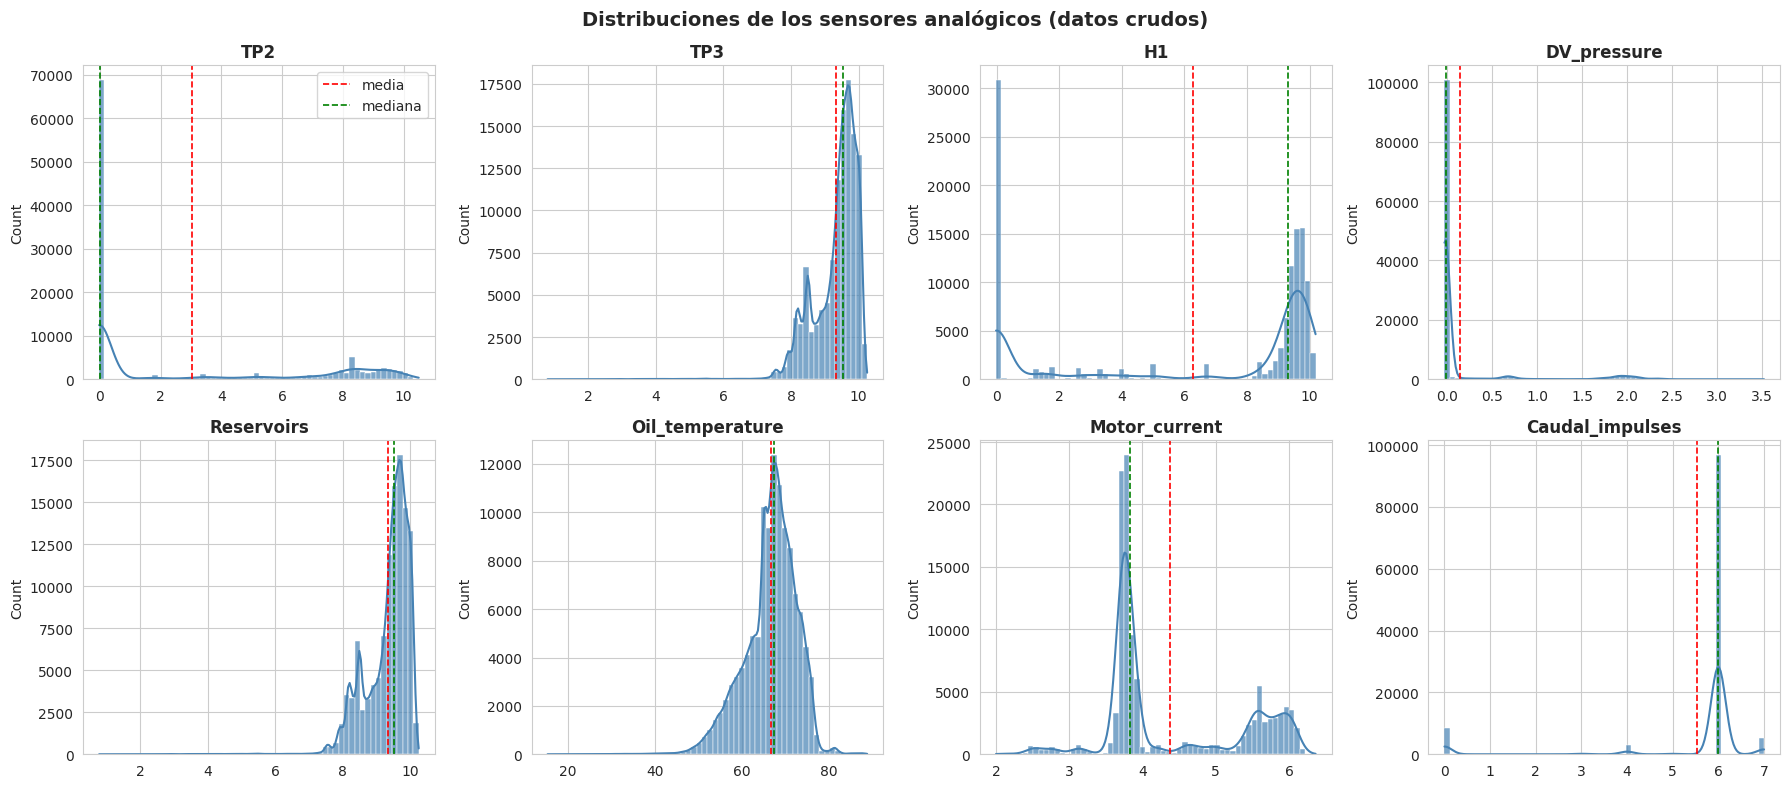

In [60]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, ANALOG_COLS):
    sns.histplot(df[col], bins=60, kde=True, ax=ax, color='steelblue', alpha=0.7)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.2, label='media')
    ax.axvline(df[col].median(), color='green',  linestyle='--', linewidth=1.2, label='mediana')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

axes[0].legend(fontsize=10)
plt.suptitle('Distribuciones de los sensores analógicos (datos crudos)', fontsize=14, fontweight='bold')
plt.tight_layout()

**TP2 -  PRESION DEL COMPRESOR:** Tiene una gran cantidad de valores en 0, y una cola hacia 8 - 10 bar.

**TP3 y Reservoirs:** concentración de valores de o a 10 bar.

**H1 - Caída de presión del filtro ciclónico:** gran masa de valores en 0 y con colas de 8 a 10 bar

**DV_pressure - Caída en torres secadoras:** Casi todo en 0 bar, lo que significa que se está trabajando bajo carga

**Motor_current - Corriente del motor:** Se puede notar que la mayor parte del tiempo el motor est+a funcionando sin carga estando en 4A.
*   4A motor trabajando sin carga
*   7A motor trabajando bajo carga


**Oil_temperature:** Distribución entre 45 y 80

**Caudal_impulses - Pulsos en el flujo de aire:** la distribución está muy concentrada en 6

## 4. Sensores binarios — activación y comportamiento temporal

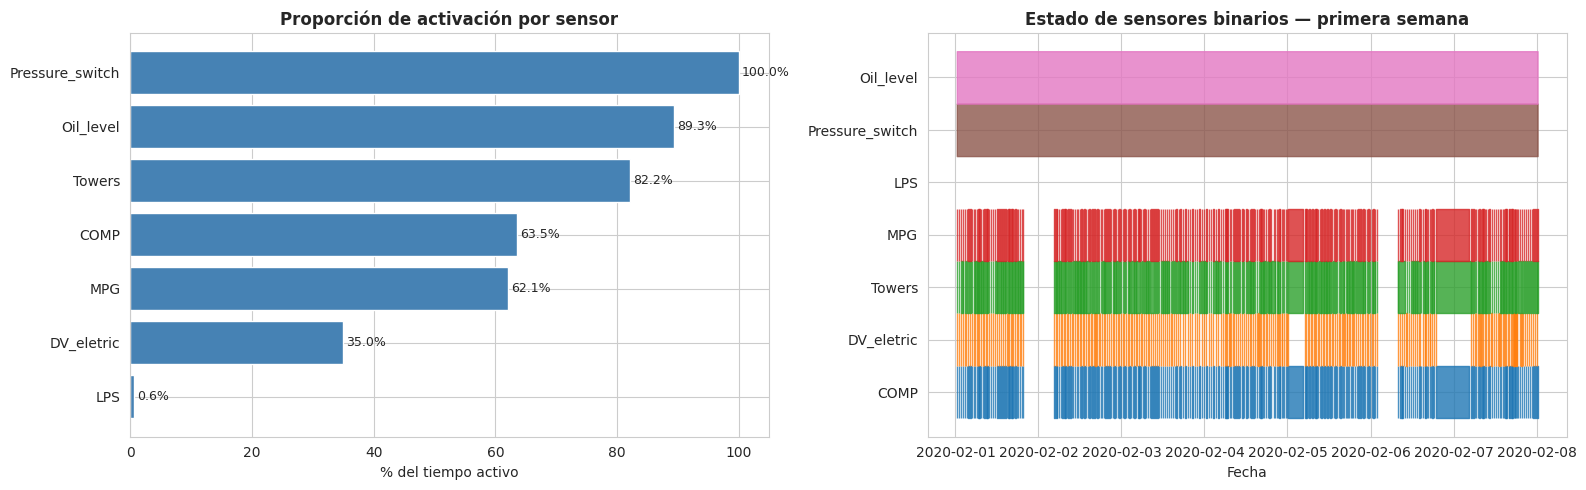

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Izquierda: proporción activa por sensor
proportions = df[BINARY_COLS].mean().sort_values() * 100
axes[0].barh(proportions.index, proportions.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('% del tiempo activo')
axes[0].set_title('Proporción de activación por sensor', fontweight='bold')
for i, v in enumerate(proportions.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# Derecha: estado de los sensores en la primera semana (vista tipo Gantt)
week = df[df['timestamp'] < df['timestamp'].min() + pd.Timedelta('7D')].copy()
colors = plt.cm.tab10.colors
for i, col in enumerate(BINARY_COLS):
    on_mask = week[col] == 1
    axes[1].fill_between(week['timestamp'], i + week[col], i,
                        where=on_mask, color=colors[i], alpha=0.8, label=col)

axes[1].set_yticks(np.arange(len(BINARY_COLS)) + 0.5)
axes[1].set_yticklabels(BINARY_COLS)
axes[1].set_title('Estado de sensores binarios — primera semana', fontweight='bold')
axes[1].set_xlabel('Fecha')

plt.tight_layout()

## Comparación EDA: Datos Crudos vs Datos Operacionales

### Sensores Binarios — Cambios en proporción de activación

| Sensor | Datos Crudos | Datos Operacionales | Cambio | Interpretación |
|--------|-------------|---------------------|--------|----------------|
| Pressure_switch | 99.1% | 100.0% | +0.9% | Sin cambio relevante — siempre activo independiente del estado |
| Oil_level | 90.4% | 89.3% | -1.1% | Estable — no depende del régimen operacional |
| Towers | 92.0% | 82.2% | -9.8% | Baja al filtrar apagados — ciclo de secado activo principalmente en operación |
| COMP | 83.7% | 63.5% | -20.2% | Baja porque COMP=0 (admisión activa) ocurre más en operación bajo carga |
| MPG | 83.3% | 62.1% | -21.2% | Consistente con COMP — ambas señales se comportan igual por diseño |
| DV_eletric | 16.1% | 35.0% | +18.9% | **Cambio más relevante** — refleja el 35% del tiempo en régimen bajo carga |
| LPS | 0.3% | 0.6% | +0.3% | Duplica pero sigue siendo raro — evento de baja presión poco frecuente en operación normal |

### Hallazgos clave

**DV_eletric** es el cambio más significativo y confirma la consistencia del preprocesamiento:
- En datos crudos aparecía poco activo porque el compresor estaba apagado la mayor parte del tiempo
- En datos operacionales refleja exactamente el porcentaje de régimen bajo carga (40,153 / 114,740 = **35%**)

**COMP y MPG** bajan de forma consistente entre sí, lo cual es esperado dado que el paper documenta que ambas señales tienen el mismo comportamiento por diseño del sistema.

**LPS** sigue siendo una señal de activación rara (0.6%) en condiciones normales de operación. Su frecuencia de activación será una feature de ingeniería clave para detectar degradación previa a fallas — se espera que aumente conforme el sistema se aproxima a un evento de falla de presión.

### Validación del preprocesamiento

La suma de los regímenes operacionales es consistente internamente:
- Régimen 2 (bajo carga, DV_eletric=1): **35%** del tiempo operacional
- Régimen 1 (sin carga, DV_eletric=0): **65%** del tiempo operacional
- Total: **100%** 

Esto confirma que el filtrado por régimen operacional capturó correctamente los estados del compresor y que los datos operacionales son internamente consistentes.